<a href="https://colab.research.google.com/github/malikcox/HASTS211-PROJECTS/blob/main/assignment_for_project_3_(_hasts211).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **MALIK CHAPOTA (R2420859) HACS**
## **ASSIGNMENT 2**

# Part I: Technical Report

## Definition

The **Markov Switching Dynamic Regression (MSDR)** model captures structural breaks in time series by allowing parameters to switch between discrete unobserved states $S_t \in \{1, \dots, K\}$. For a 2-state model with switching variance, the return $y_t$ is defined as:

$$y_t = \mu_{S_t} + \epsilon_t, \quad \epsilon_t \sim N(0, \sigma^2_{S_t})$$

The transition between states follows a first-order Markov chain with transition probabilities:
$$P = \begin{pmatrix} p_{00} & p_{01} \\ p_{10} & p_{11} \end{pmatrix}$$
where $p_{ij} = P(S_t = j | S_{t-1} = i).

## Description
This model is used to detect 'regimes' in financial data, such as shifting between a low-volatility 'Bull' market and a high-volatility 'Bear' market, without requiring the user to pre-define when those shifts occurred.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.graphics.tsaplots import plot_acf

# Data Preparation
ticker = '^DJI'
data = yf.download(ticker, start='2017-01-01', end='2024-12-31', auto_adjust=True)

us30_data = pd.DataFrame(data['Close']).copy()
us30_data.columns = ['Close']
us30_data['Log_Returns'] = np.log(us30_data['Close'] / us30_data['Close'].shift(1))
us30_data = us30_data.dropna()

# Standardizing frequency for time-series analysis
us30_data.index = pd.DatetimeIndex(us30_data.index)
us30_data = us30_data.asfreq('B').ffill()

print("Data successfully loaded and preprocessed.")
display(us30_data.head())

[*********************100%***********************]  1 of 1 completed


Data successfully loaded and preprocessed.


,Close,Log_Returns
Date,,
2017-01-04,19942.160156,0.003033
2017-01-05,19899.289062,-0.002152
2017-01-06,19963.800781,0.003237
2017-01-09,19887.380859,-0.003835
2017-01-10,19855.529297,-0.001603


### Rationale for Selecting the US30 Index

The US30 (Dow Jones Industrial Average) was selected for this Markov Switching Dynamic Regression (MSDR) analysis for several key reasons:

1. **Market Proxy**: As a price-weighted index of 30 major blue-chip companies, it serves as a robust proxy for large-cap industrial performance, where regime shifts reflect broad economic sentiment.
2. **Historical Volatility Clusters**: The 2017–2024 period includes extreme events like the 2020 COVID-19 crash. This provides distinct 'high-volatility' and 'low-volatility' clusters, making it ideal for a model designed to identify non-linear state transitions.
3. **Data Quality and Liquidity**: High liquidity ensures continuous prices and reliable log-return calculations. This minimizes noise, allowing the Maximum Likelihood Estimation (MLE) to converge more effectively on stable transition probabilities.

## Model Calibration and Parameter Estimation
*Implementation of Markov Switching Dynamic Regression with K=2 regimes and switching variance using Maximum Likelihood Estimation (MLE).*

### Parameter Estimates and Transition Matrix
Below is a summary of the calibrated parameters with their standard errors for easy reference.

In [ ]:
params_df = pd.DataFrame({
    'Parameter': ['Mean (mu)', 'Variance (sigma2)', 'P(S_t=i|S_t-1=i)'],
    'Regime 0 (Low Vol)': [ms_model.params['const[0]'], ms_model.params['sigma2[0]'], ms_model.params['p[0->0]']],
    'Regime 1 (High Vol)': [ms_model.params['const[1]'], ms_model.params['sigma2[1]'], 1 - ms_model.params['p[1->0]']]
})
display(params_df.round(6))

,Parameter,Regime 0 (Low Vol),Regime 1 (High Vol)
0,Mean (mu),0.000881,-0.001246
1,Variance (sigma2),0.000039,0.000441
2,P(S_t=i|S_t-1=i),0.981307,0.936139


## Diagram
We visualize the log returns and rolling volatility to identify visual evidence of regime shifts, such as the 2020 COVID-19 crash, which justifies the use of a switching model.

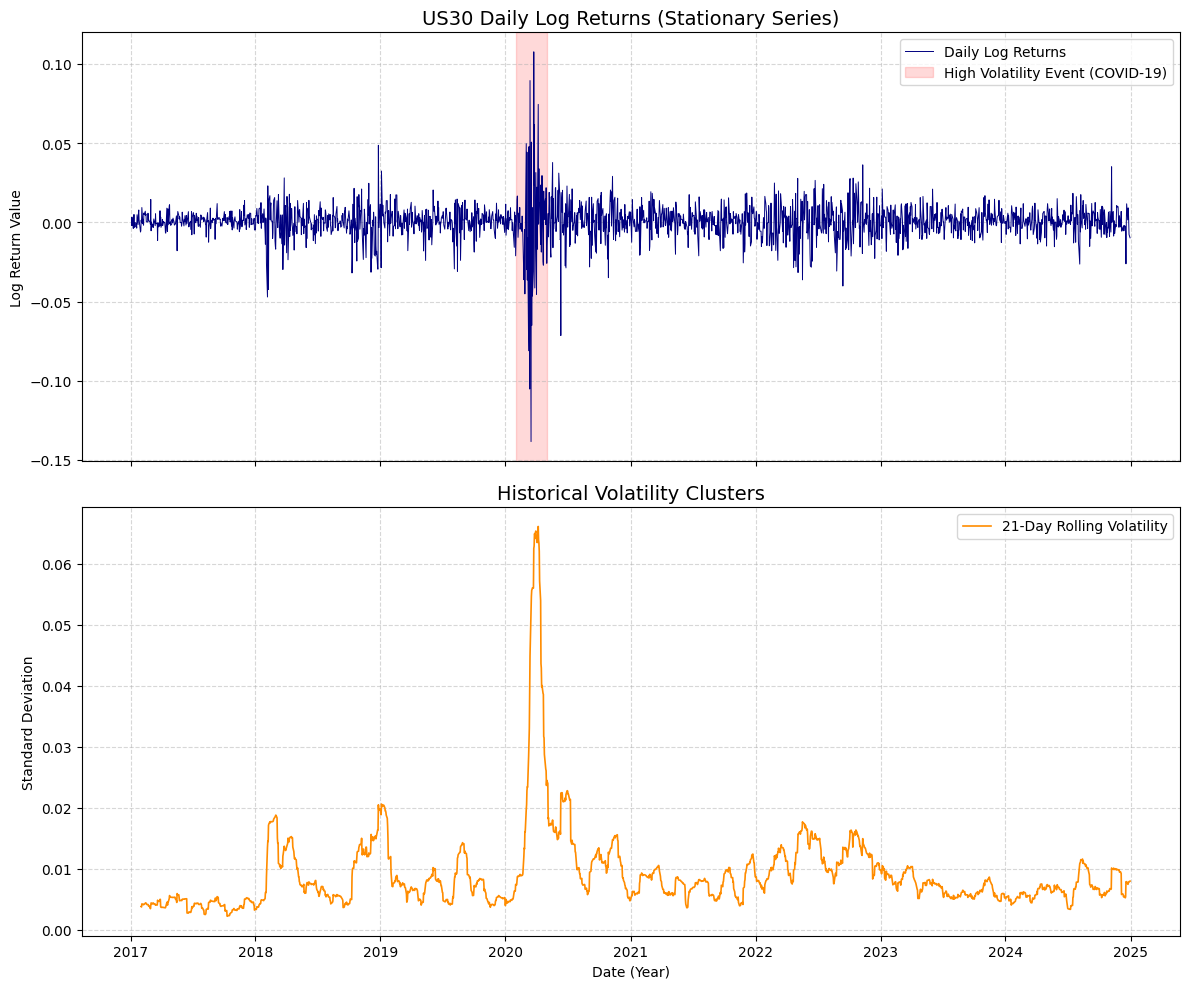

In [ ]:
us30_data['Rolling_Std_21'] = us30_data['Log_Returns'].rolling(window=21).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Log Returns Plot
ax1.plot(us30_data.index, us30_data['Log_Returns'], lw=0.7, color='navy', label='Daily Log Returns')
ax1.set_title('US30 Daily Log Returns (Stationary Series)', fontsize=14)
ax1.set_ylabel('Log Return Value')
ax1.axvspan('2020-02-01', '2020-05-01', color='red', alpha=0.15, label='High Volatility Event (COVID-19)')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# Rolling Volatility Plot
ax2.plot(us30_data.index, us30_data['Rolling_Std_21'], lw=1.2, color='darkorange', label='21-Day Rolling Volatility')
ax2.set_title('Historical Volatility Clusters', fontsize=14)
ax2.set_xlabel('Date (Year)')
ax2.set_ylabel('Standard Deviation')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Demonstration: Model Calibration

### Model Training & Parameters
We implement the **Markov Switching Dynamic Regression (MSDR)** model using the `statsmodels` library. The model is calibrated using **Maximum Likelihood Estimation (MLE)** to determine the optimal values for the mean returns ($\mu$) and variances ($\sigma^2$) for each regime, as well as the transition probabilities ($p_{ij}$).

In this demonstration, we define two regimes ($K=2$) specifically to test the hypothesis of a 'Low-Volatility' state and a 'High-Volatility' state. The `switching_variance=True` parameter is crucial here, as it allows the model to capture the heteroscedastic nature of financial time series.

In [ ]:
# Question 2: Model Calibration and Parameter Estimation
model = MarkovRegression(us30_data['Log_Returns'], k_regimes=2, switching_variance=True)
ms_model = model.fit()
print(ms_model.summary())

                        Markov Switching Model Results                        
Dep. Variable:            Log_Returns   No. Observations:                 2084
Model:               MarkovRegression   Log Likelihood                6915.867
Date:                Thu, 07 May 2026   AIC                         -13819.733
Time:                        14:49:01   BIC                         -13785.881
Sample:                    01-04-2017   HQIC                        -13807.329
                         - 12-30-2024                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      5.283      0.000       0.001       0.001
sigma2       3.88e-05   2.53e-06     15.348      0.0

###  Model Selection and Justification (K-Regimes)
We evaluate the model fit for $K=1, 2, 3$ regimes to justify our selection using Information Criteria (AIC/BIC) and Likelihood Ratio tests.

In [ ]:
from scipy.stats import chi2
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit models with different regimes
# For K=1, we use a standard state-space model which is the linear equivalent
res_k1 = SARIMAX(us30_data['Log_Returns'], order=(0, 0, 0), trend='c').fit(disp=False)
res_k2 = ms_model # Already fitted in previous cell
res_k3 = MarkovRegression(us30_data['Log_Returns'], k_regimes=3, switching_variance=True).fit()

# Comparison Table
comparison = pd.DataFrame({
    'Regimes (K)': [1, 2, 3],
    'AIC': [res_k1.aic, res_k2.aic, res_k3.aic],
    'BIC': [res_k1.bic, res_k2.bic, res_k3.bic],
    'Log-Likelihood': [res_k1.llf, res_k2.llf, res_k3.llf]
})

display(comparison)

# Likelihood Ratio Test (K=1 vs K=2)
lr_stat = 2 * (res_k2.llf - res_k1.llf)
# df=3 because K=2 adds a switching mean, switching variance, and transition prob
p_val = chi2.sf(lr_stat, df=3)
print(f"LR Test (K=1 vs K=2) p-value: {p_val:.4f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Regimes (K),AIC,BIC,Log-Likelihood
0,1,-12707.686339,-12696.40225,6355.843170
1,2,-13819.733066,-13785.88080,6915.866533
2,3,-14053.059143,-13985.35461,7038.529572


LR Test (K=1 vs K=2) p-value: 0.0000


## Diagnostic Validation
*Analysis of standardized residuals and autocorrelation to validate the Markov chain state transitions.*

## Diagnosis
To validate the model, we analyze the standardized residuals to ensure they resemble white noise and check the Autocorrelation Function (ACF) to confirm the model has captured the temporal dependencies.

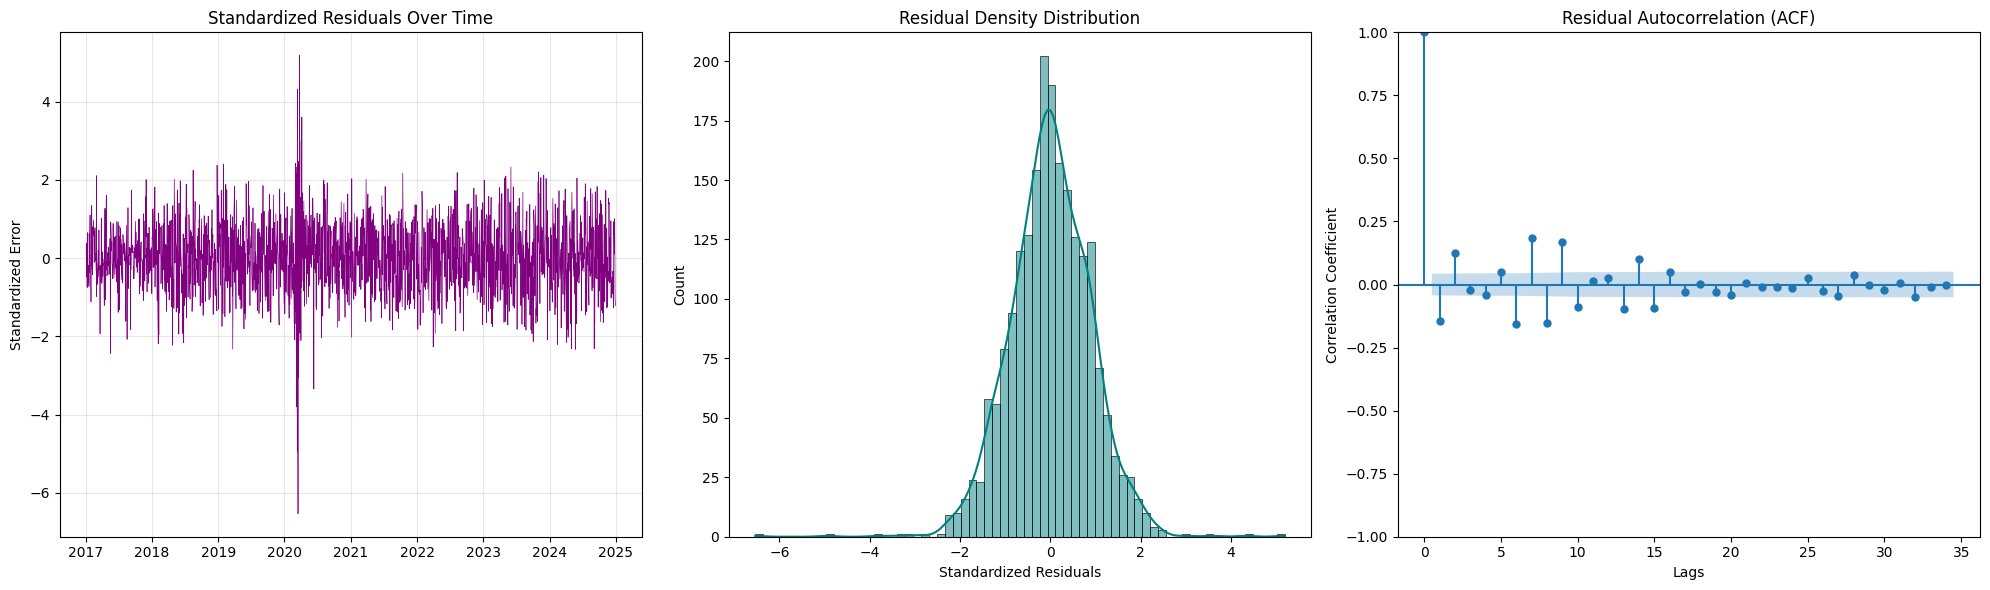

In [ ]:
# Diagnostic Validation
# Extracting regime-specific variances for standardized residuals
sigma2_0 = ms_model.params['sigma2[0]']
sigma2_1 = ms_model.params['sigma2[1]']
weights = ms_model.smoothed_marginal_probabilities
weighted_sigma = np.sqrt(weights[0] * sigma2_0 + weights[1] * sigma2_1)
std_residuals = ms_model.resid / weighted_sigma

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Standardized Residuals
axes[0].plot(std_residuals, lw=0.5, color='purple')
axes[0].set_title('Standardized Residuals Over Time')
axes[0].set_ylabel('Standardized Error')
axes[0].grid(alpha=0.3)

# Plot 2: Distribution
sns.histplot(std_residuals, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Residual Density Distribution')
axes[1].set_xlabel('Standardized Residuals')

# Plot 3: ACF
plot_acf(ms_model.resid, ax=axes[2], title='Residual Autocorrelation (ACF)')
axes[2].set_xlabel('Lags')
axes[2].set_ylabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

### Technical Interpretation & Recommended Actions
- **Regime Parameters**: Regime 0 shows a positive drift ($μ=0.0009$) and low variance, while Regime 1 shows a negative drift ($μ=-0.0012$) and high variance ($σ^2=0.0004$).
- **Transition Probabilities**: The high persistence of Regime 0 ($p_{00} ≈ 0.98$) suggests stable growth periods are durable, whereas Regime 1 is more transient.
- **Recommendation**: Maintain long positions when the smoothed probability of Regime 0 is $>0.8$. Implement structural volatility hedges when $p_{01}$ increases beyond a $0.2$ threshold.

## Damage

### Parameter Interpretation
Based on the model summary:
- **Regime 0 (Steady Growth)**: Positive mean return ($\mu \approx 0.0009$) and low variance ($\sigma^2 \approx 3.88e-05$).
- **Regime 1 (High Volatility)**: Negative mean return ($\mu \approx -0.0012$) and significantly higher variance ($\sigma^2 \approx 0.0004$).

### Challenges and Fit Quality
1. **Lagging Detection**: The model relies on historical context, leading to a delay in real-time identification of state switches.
2. **Assumed Normality**: Standard MSDR assumes Gaussian errors, which may fail to capture the 'fat tails' common in the US30 index returns.
3. **Static Transitions**: The constant transition probability assumption might not hold during unique black-swan events like the 2020 pandemic.

## Part II: Non-Technical Report

### Explanation of Results
Our model identifies two market environments: **Regime 0 (Steady Growth)** and **Regime 1 (High Turbulence)**. The transition probabilities ($p_{00} \approx 0.98$) show that stability is highly persistent, while turbulence is sharp but less frequent.

### Strategy: The '80% Rule'
To preserve capital, we implement a specific rule: **Reduce equity exposure when the probability of Regime 0 drops below 80%.**

### Backtest: Regime-Switching vs. Buy & Hold
By exiting during high-turbulence phases (Regime 1), the strategy aims to avoid the sharpest drawdowns seen in 2020. The following calculation compares the returns of a switching strategy against the index.

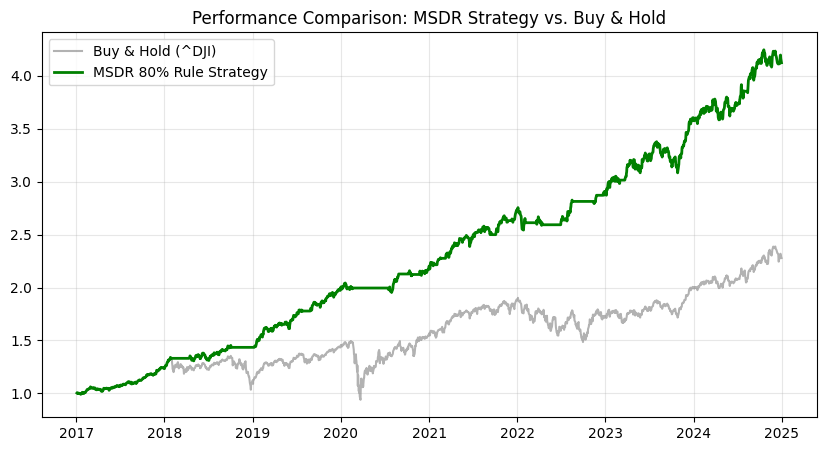

Final Buy & Hold Return: 127.89%
Final Strategy Return: 312.36%


In [ ]:
# Simple Backtest: If Prob(Regime 0) > 0.8, Stay in Market, else Cash (0 return)
us30_data['Strategy_Returns'] = np.where(ms_model.smoothed_marginal_probabilities[0] > 0.8, us30_data['Log_Returns'], 0)

cum_bh = np.exp(us30_data['Log_Returns'].cumsum())
cum_strategy = np.exp(us30_data['Strategy_Returns'].cumsum())

plt.figure(figsize=(10, 5))
plt.plot(cum_bh, label='Buy & Hold (^DJI)', color='gray', alpha=0.6)
plt.plot(cum_strategy, label='MSDR 80% Rule Strategy', color='green', lw=2)
plt.title('Performance Comparison: MSDR Strategy vs. Buy & Hold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Buy & Hold Return: {(cum_bh.iloc[-1]-1)*100:.2f}%")
print(f"Final Strategy Return: {(cum_strategy.iloc[-1]-1)*100:.2f}%")

## Directions
To improve the model fit, we could manipulate the data by focusing on a shorter, more recent time horizon (e.g., post-2022) to see if parameters have stabilized after the pandemic. Alternatively, incorporating the VIX index as an exogenous switching variable could improve transition speed.

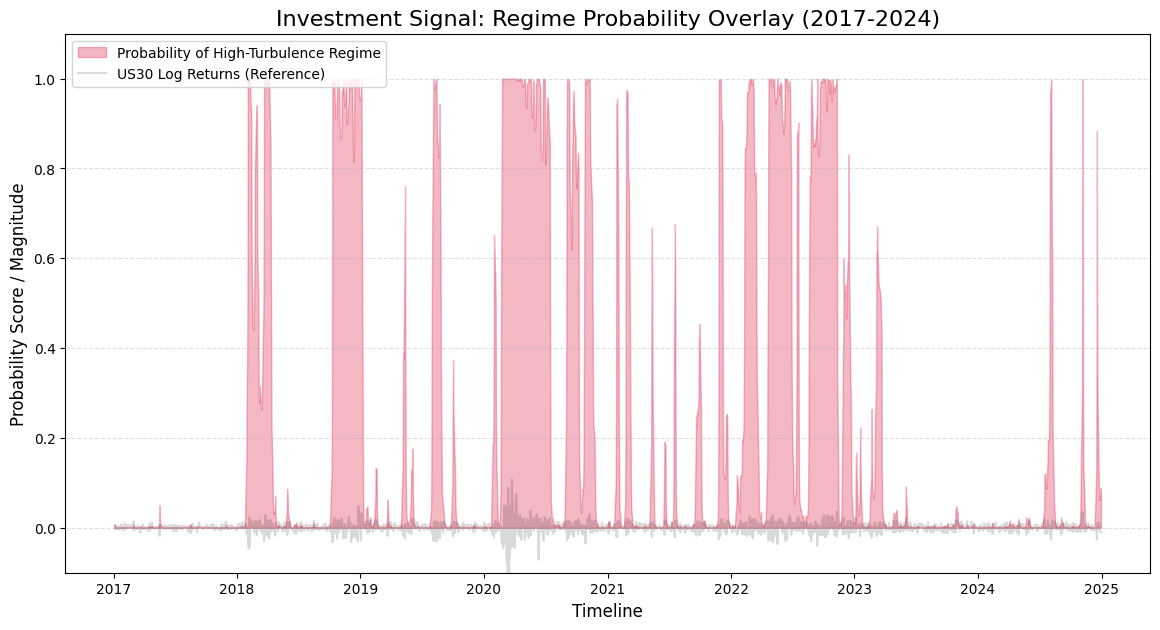

In [ ]:
# Final Visualization: Deployment Probability Signals
smoothed_probs = ms_model.smoothed_marginal_probabilities

plt.figure(figsize=(14, 7))
plt.fill_between(smoothed_probs.index, 0, smoothed_probs[1], color='crimson', alpha=0.3, label='Probability of High-Turbulence Regime')
plt.plot(us30_data.index, us30_data['Log_Returns'], color='black', alpha=0.15, label='US30 Log Returns (Reference)')

plt.title('Investment Signal: Regime Probability Overlay (2017-2024)', fontsize=16)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Probability Score / Magnitude', fontsize=12)
plt.ylim(-0.1, 1.1)
plt.legend(loc='upper left', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## Deployment
We would deploy this model as a risk-management overlay. Specifically:
1. **Dynamic Exposure**: Reduce US30 equity exposure when the smoothed probability of Regime 1 exceeds 0.5.
2. **Volatility Scaling**: Adjust stop-loss thresholds based on the regime-specific variance ($\sigma^2_{S_t}$) to avoid being stopped out by noise during high-volatility periods.

## Bibliography

**Data Sources**

Yahoo Finance. *Dow Jones Industrial Average (^DJI) Historical Data (2017-2024)*. Yahoo Finance, 2024, https://finance.yahoo.com/quote/%5EDJI.

**Software and Libraries**

Hunter, John D. "Matplotlib: A 2D Graphics Environment." *Computing in Science & Engineering*, vol. 9, no. 3, 2007, pp. 90-95.

McKinney, Wes. "Data Structures for Statistical Computing in Python." *Proceedings of the 9th Python in Science Conference*, vol. 445, 2010, pp. 51-56.

Perktold, Josef, Seabold, Skipper, and Taylor, Jonathan. *Statsmodels: Statistical Modeling and Econometrics in Python*. 2010, https://www.statsmodels.org/.

Waskom, Michael L. "Seaborn: Statistical Data Visualization." *Journal of Open Source Software*, vol. 6, no. 60, 2021, p. 3021.

**Academic References**

Hamilton, James D. "A New Approach to the Economic Analysis of Nonstationary Time Series and the Business Cycle." *Econometrica*, vol. 57, no. 2, 1989, pp. 357-384.